# 🧠 07. Treinamento do Modelo - xgboost com dados processados

 objetivo do notebook é pegar o modelo xgb com o dados processados para fazer previsão

## 🛠️  Imports e Configurações

### Pacotes

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from datetime import datetime
from IPython.display import display

from src.tools import config_default, load_config
from src.features import (fengineering_1_ordenar,
                               fengineering_2_datas_feriados,
                               fengineering_3_lag1_lag7,
                               fengineering_4_cyclical,
                               fengineering_5_lags,
                               fengineering_6_rolling,
                               fengineering_7_final,
                               fengineering_8_gerar_arquivo
                               )

import warnings
warnings.filterwarnings('ignore')


### Configurações gerais

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

PATH_MODELO = '../models/xgb_model.json' # ou .json, dependendo de como salvou
# PATH_PREPROCESSOR = '../models/preprocessor.pkl'
PATH_HISTORICO = '../data/processed/dados_com_features.csv'   #notebook 02

#🚩
retorno = config_default()  
ORDENACAO_BASE_BUSCA = retorno[0]
TARGET_PROJETO = retorno[1]
PATH_RAW = retorno[2]
EXCLUIR_COLUNA_MODELO = retorno[3]
SPLIT_DATE = retorno[4]

LISTA_LOJAS = [1, 2, 9, 10]
LISTA_ITENS = [1, 4]

TARGET_ITEM = 1
TARGET_PROJETO = 'sales'
NOME_ARQUIVO_METRICAS = "../data/metrics/metricas_lojas.csv"


Ordenação das colunas: ['store', 'item', 'date']


In [4]:
# carrega o modelo

model = xgb.Booster()
print("Carregando modelo XGBoost...")
if not os.path.exists(PATH_MODELO):
    print(f"🔴 ERRO CRÍTICO: O arquivo não foi encontrado no caminho: {PATH_MODELO}")
    print("Verifique se o nome do arquivo ou a pasta '../models' estão corretos.")
    exit(1)
else:
    model.load_model(PATH_MODELO)

Carregando modelo XGBoost...


In [5]:
print(" Carregando e Preparando Base Global (Aguarde)...")

df_train = pd.read_csv(PATH_HISTORICO)
df_test = pd.read_csv(PATH_RAW)

df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# Salvar Gabarito
gabarito_global = df_test[['date', 'store', 'item', 'sales']].copy()
gabarito_global = gabarito_global.rename(columns={'sales': 'sales_real'})

# Preparar Dados
df_test['sales'] = float('nan')
max_lag_days = 120
data_corte = df_test['date'].min() - pd.Timedelta(days=max_lag_days)
df_train_buffer = df_train[df_train['date'] >= data_corte].copy()

# Aplicar LOG no histórico global
df_train_buffer['sales'] = np.log1p(df_train_buffer['sales'])

# Concatenar
df_global = pd.concat([df_train_buffer, df_test], ignore_index=True)

# Booleans
cols_bool = ['is_weekend', 'is_payday', 'is_holiday', 'is_school_holiday']
for col in cols_bool:
    if col in df_global.columns:
        df_global[col] = df_global[col].astype(bool).astype(int)

print(f"   Base Global Pronta. Total de linhas: {len(df_global)}")
print(f"   Lojas Selecionadas: {LISTA_LOJAS}")
print("-" * 50)


 Carregando e Preparando Base Global (Aguarde)...
   Base Global Pronta. Total de linhas: 106000
   Lojas Selecionadas: [1, 2, 9, 10]
--------------------------------------------------


In [6]:
# MOTOR DE PREVISÃO (RECURSIVO)

def previsao_recursiva_lote(model, df_test_base, feature_order, target_col='sales'):
    df_sim = df_test_base.copy()
    df_sim = df_sim.sort_values('date').reset_index(drop=True)
    
    lags = [1, 2, 3, 7, 14, 21, 28, 91]
    windows = [7, 28, 91]
    
    # Identificar onde começam os nulos (futuro desconhecido)
    if df_sim[target_col].isna().any():
        first_nan_idx = df_sim[target_col].isna().idxmax()
    else:
        # Fallback: se não tiver nulos, pega os ultimos 90 dias para simular teste cego
        first_nan_idx = max(0, len(df_sim) - 90)
    
    # Loop Recursivo
    for i in range(first_nan_idx, len(df_sim)):
        
        # 1. Atualizar Features de Lag (Dependem do target passado)
        for lag in lags:
            if (i - lag) >= 0:
                df_sim.at[i, f'lag_{lag}'] = df_sim.at[i - lag, target_col]
        
        # 2. Atualizar Features de Janela Móvel (Rolling)
        for w in windows:
            start = i - w
            if start >= 0:
                subset = df_sim[target_col].iloc[start : i]
                df_sim.at[i, f'rolling_mean_{w}'] = subset.mean()
                df_sim.at[i, f'rolling_std_{w}'] = subset.std()
        
        # Nota: Features de Data (Seno, Cosseno, Feriado) já são estáticas 
        # e foram calculadas antes de entrar neste loop pelas funções de engenharia.

        # 3. Prever
        row_features = df_sim.iloc[[i]][feature_order]
        
        # Tratamento para XGBoost (DMatrix)
        dmatrix_row = xgb.DMatrix(row_features, enable_categorical=True)
        pred_log = model.predict(dmatrix_row)[0]
        
        # 4. Gravar Previsão para usar na próxima iteração
        df_sim.at[i, target_col] = pred_log
        df_sim.at[i, 'pred_final_real'] = np.expm1(pred_log) 

    return df_sim


In [7]:
# EXECUÇÃO DO PROCESSO EM LOTE

# Verifica se os objetos globais existem
if 'df_global' not in locals():
    print("ERRO CRÍTICO: 'df_global' e 'model' precisam estar carregados.")
else:
    print(f"--- INICIANDO PROCESSO PARA {len(LISTA_ITENS)} ITENS EM {len(LISTA_LOJAS)} LOJAS ---")

    csv_output_data = []
    plot_data = {} 

    # Features esperadas pelo modelo
    if hasattr(model, 'feature_names'):
        features_cols = model.feature_names
    else:
        features_cols = [] 

    # === LOOP DUPLO: ITEM -> LOJA ===
    for item_id in LISTA_ITENS:
        print(f"\n>>> Processando ITEM {item_id}...")
        
        for loja_id in LISTA_LOJAS:
            print(f"   > Loja {loja_id}: ", end="")
            
            try:
                # A. Filtrar Dados
                if 'data_corte' not in locals(): 
                    data_corte = df_global['date'].max() - pd.Timedelta(days=120)

                df_subset = df_global[
                    (df_global['store'] == loja_id) & 
                    (df_global['item'] == item_id) &
                    (df_global['date'] >= data_corte)
                ].copy().sort_values('date').reset_index(drop=True)
                
                if len(df_subset) == 0:
                    print("Sem dados.")
                    continue

                # B. APLICAÇÃO DAS FEATURES
                df_subset = fengineering_2_datas_feriados(df_subset, TARGET_PROJETO)
                df_subset = fengineering_4_cyclical(df_subset)

                # C. Executar Simulação Recursiva
                df_res = previsao_recursiva_lote(model, df_subset, features_cols)
                
                # D. Validar Resultados (Comparar com Real)
                df_analise = df_res.dropna(subset=['pred_final_real']).copy()
                
                # Recuperar Gabarito
                if 'gabarito_global' in locals():
                    gab_loja = gabarito_global[
                        (gabarito_global['store'] == loja_id) & 
                        (gabarito_global['item'] == item_id)
                    ]
                    df_analise = df_analise.merge(gab_loja[['date', 'sales_real']], on='date', how='left')
                    df_analise = df_analise.dropna(subset=['sales_real'])

                # Cálculo de Métricas e Salvamento
                if 'sales_real' in df_analise.columns and len(df_analise) > 0:
                    y_true = df_analise['sales_real']
                    
                    # Ajuste de viés
                    bias = df_analise['pred_final_real'].mean() - y_true.mean()
                    df_analise['pred_corrigida'] = df_analise['pred_final_real'] - bias
                    y_pred = df_analise['pred_corrigida']
                    
                    # --- CÁLCULO DE TODAS AS MÉTRICAS (Para evitar o erro de chave) ---
                    mae = mean_absolute_error(y_true, y_pred)
                    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                    r2 = r2_score(y_true, y_pred)
                    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
                    
                    # MAPE (evitando divisão por zero)
                    mape_val = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
                    
                    # Preencher o dicionário COM TODAS AS CHAVES que o pandas vai pedir depois
                    csv_output_data.append({
                        'Data': datetime.now().strftime('%Y-%m-%d'),
                        'Notebook': '07_Validacao_Final',
                        'Etapa': 'Teste_MultiItem',
                        'Modelo': 'XGBoost_Final',
                        'MAE': round(mae, 2),
                        'RMSE': round(rmse, 2),
                        'WAPE (%)': round(wape * 100, 2),
                        'MAPE (%)': round(mape_val, 2),
                        'R2': round(r2, 4),
                        'Loja': loja_id,
                        'Item': item_id
                    })
                    
                    # Guardar dados para o Relatório Visual
                    plot_data[(loja_id, item_id)] = df_analise[['date', 'sales_real', 'pred_corrigida']].copy()
                    
                    print(f"OK. WAPE: {wape:.1%}")
                else:
                    print("Processado (Sem validação real).")

            except Exception as e:
                print(f"FALHA: {str(e)}")

    print("\nProcessamento Concluído!")


--- INICIANDO PROCESSO PARA 2 ITENS EM 4 LOJAS ---

>>> Processando ITEM 1...
   > Loja 1: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 19.6%
   > Loja 2: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 15.3%
   > Loja 9: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 13.8%
   > Loja 10: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07     

In [8]:
# GERAR CSV (AGORA VAI FUNCIONAR)

if len(csv_output_data) > 0:
    df_final_csv = pd.DataFrame(csv_output_data)
    
    # Lista exata de colunas que causou o erro (agora todas existem)
    cols_order = ['Data', 'Notebook', 'Etapa', 'Modelo', 'MAE', 'RMSE', 'WAPE (%)', 'MAPE (%)', 'R2', 'Loja', 'Item']
    
    # Agora o filtro funciona pois criamos todas as colunas acima
    df_final_csv = df_final_csv[cols_order]
    
    df_final_csv.to_csv(NOME_ARQUIVO_METRICAS, index=False, sep=',') 
    print(f"\nArquivo '{NOME_ARQUIVO_METRICAS}' salvo com sucesso!")
    print(df_final_csv[['Loja', 'Item', 'WAPE (%)', 'R2']].head().to_string(index=False))
else:
    print("Nenhuma métrica gerada.")




Arquivo '../data/metrics/metricas_lojas.csv' salvo com sucesso!
 Loja  Item  WAPE (%)     R2
    1     1     19.59 0.3417
    2     1     15.30 0.5551
    9     1     13.84 0.4914
   10     1     11.64 0.6445
    1     4     16.36 0.4177



GERANDO RESULTADOS


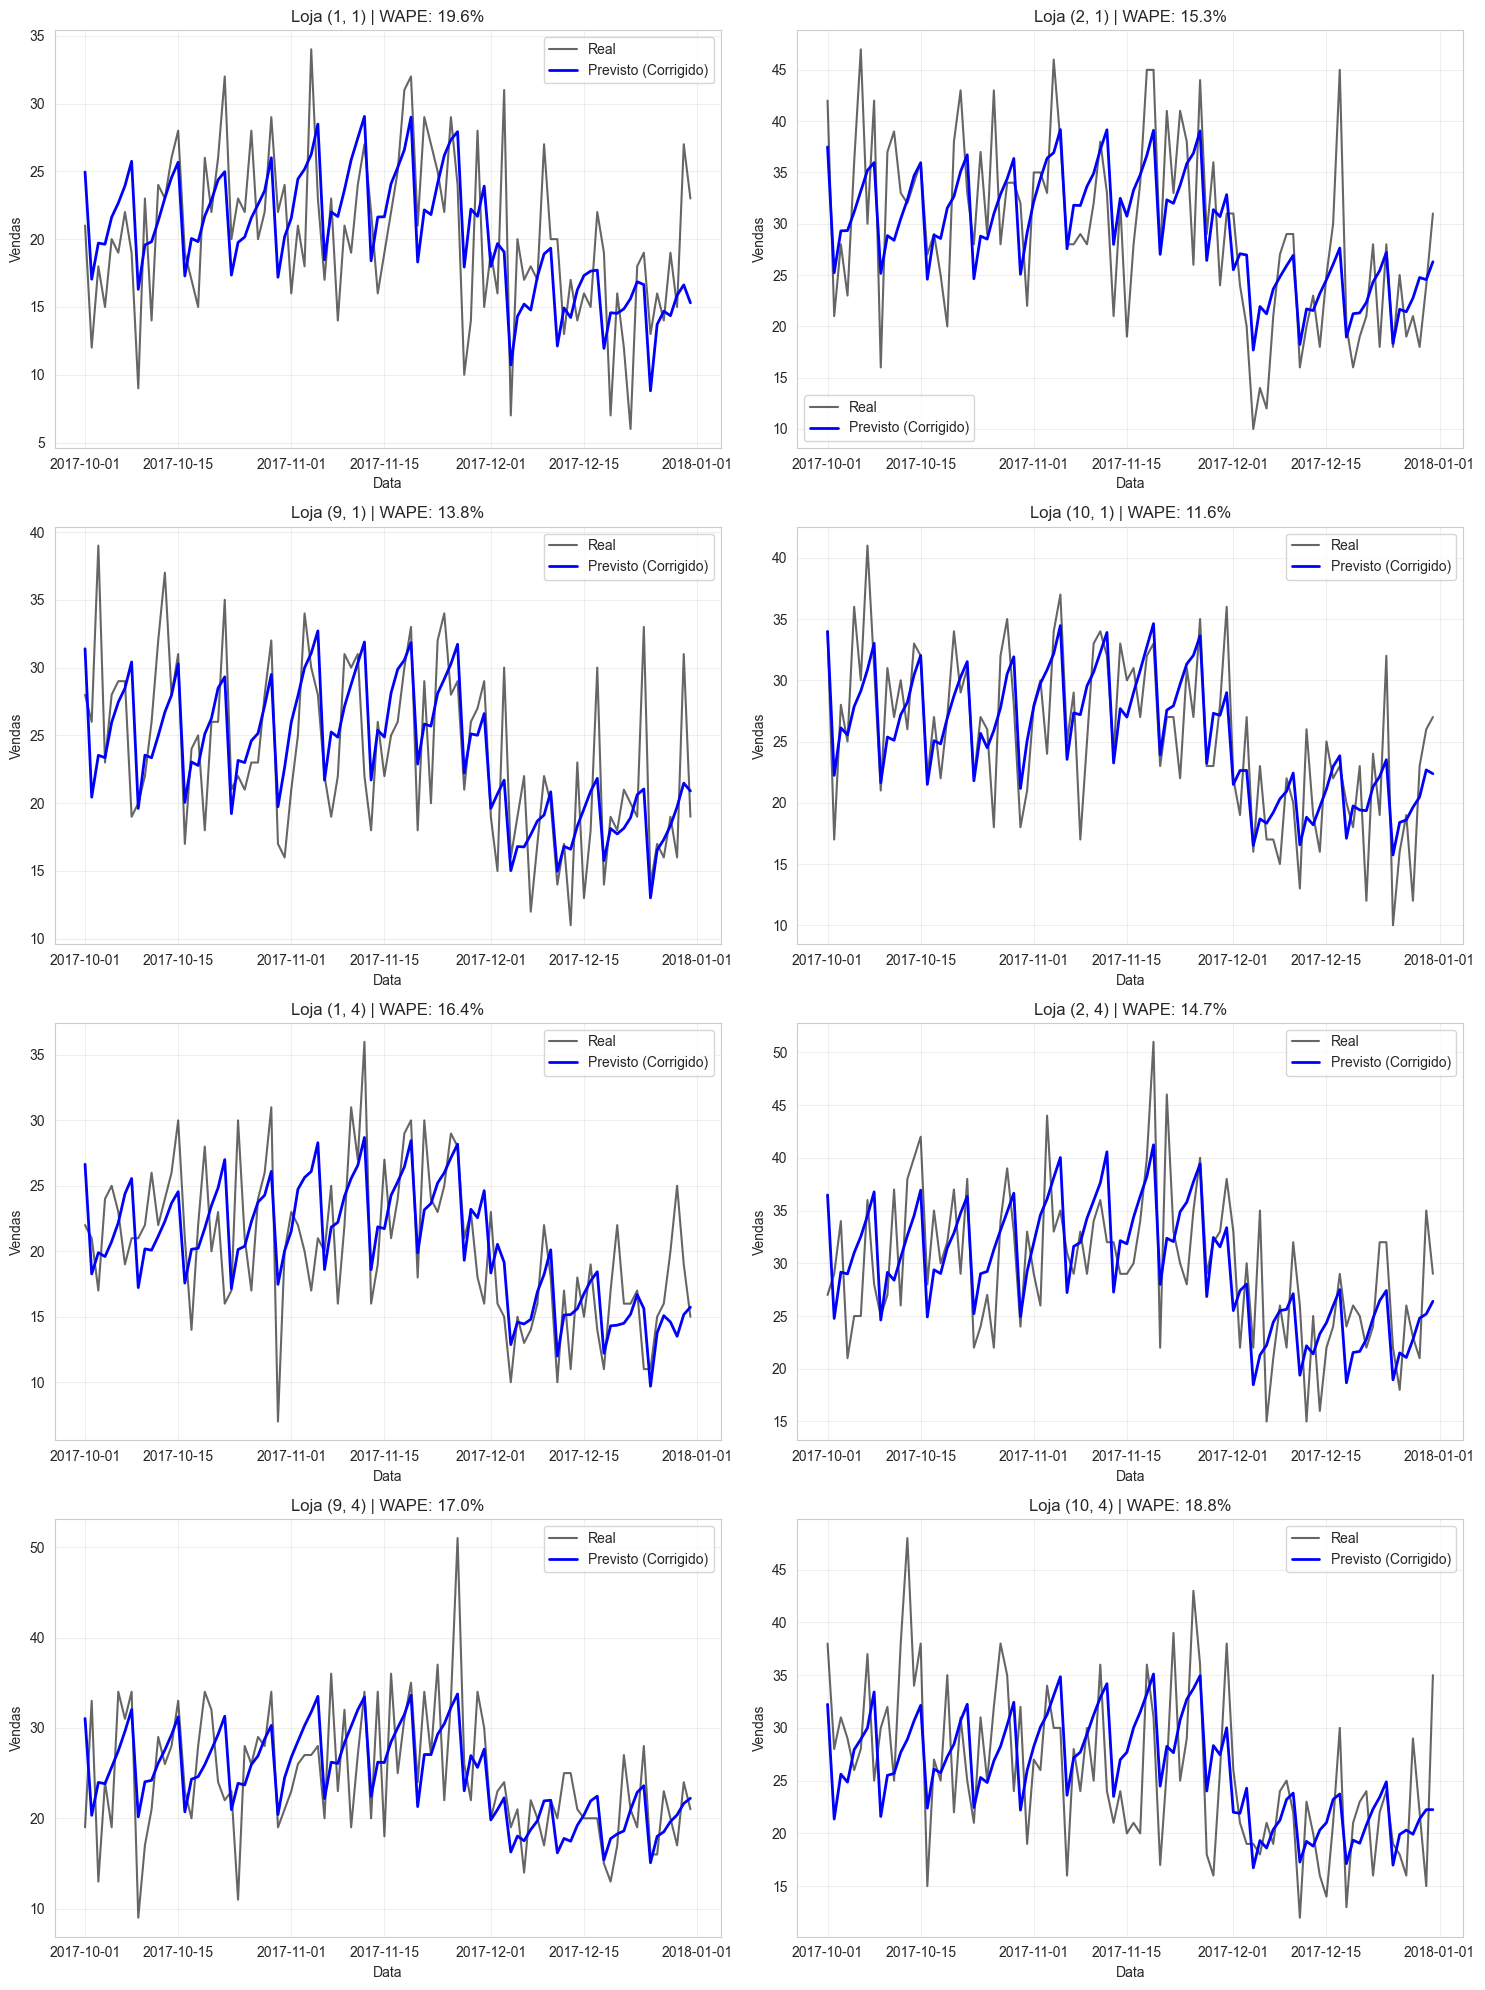

In [9]:
# 5. GERAR CSV E GRÁFICOS

print("\n" + "="*60)
print("GERANDO RESULTADOS")
print("="*60)


# Gerar Gráficos
if len(plot_data) > 0:
    num_plots = len(plot_data)
    cols = 2
    rows = (num_plots // cols) + (num_plots % cols > 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i, (loja, df_plot) in enumerate(plot_data.items()):
        ax = axes[i]
        ax.plot(df_plot['date'], df_plot['sales_real'], label='Real', color='black', alpha=0.6)
        ax.plot(df_plot['date'], df_plot['pred_corrigida'], label='Previsto (Corrigido)', color='blue', linewidth=2)
        
        # Estética
        ax.set_title(f"Loja {loja} - Item {TARGET_ITEM}")
        ax.set_xlabel('Data')
        ax.set_ylabel('Vendas')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Calcular WAPE local para mostrar no título
        y_t = df_plot['sales_real']
        y_p = df_plot['pred_corrigida']
        wape_local = np.sum(np.abs(y_t - y_p)) / np.sum(np.abs(y_t))
        ax.set_title(f"Loja {loja} | WAPE: {wape_local:.1%}")

    # Remover eixos vazios se houver
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

In [10]:
# EXECUÇÃO DO PROCESSO EM LOTE (MULTIPLOS ITENS E LOJAS)


# Verifica se os objetos globais existem
if 'df_global' not in locals():
    print("ERRO CRÍTICO: 'df_global' e 'model' precisam estar carregados.")
else:
    print(f"--- INICIANDO PROCESSO PARA {len(LISTA_ITENS)} ITENS EM {len(LISTA_LOJAS)} LOJAS ---")

    csv_output_data = []
    
    # Agora o dicionário de plot guarda pela chave (Loja, Item)
    plot_data = {} 

    # Features esperadas pelo modelo
    if hasattr(model, 'feature_names'):
        features_cols = model.feature_names
    else:
        features_cols = [] # Ajuste conforme seu notebook original se necessário

    # === LOOP DUPLO: ITEM -> LOJA ===
    for item_id in LISTA_ITENS:
        print(f"\n>>> Processando ITEM {item_id}...")
        
        for loja_id in LISTA_LOJAS:
            # Barra de progresso visual simples
            print(f"   > Loja {loja_id}: ", end="")
            
            try:
                # A. Filtrar Dados (Agora usando item_id e loja_id)
                if 'data_corte' not in locals(): 
                    data_corte = df_global['date'].max() - pd.Timedelta(days=120)

                df_subset = df_global[
                    (df_global['store'] == loja_id) & 
                    (df_global['item'] == item_id) &   # <--- AQUI MUDOU
                    (df_global['date'] >= data_corte)
                ].copy().sort_values('date').reset_index(drop=True)
                
                if len(df_subset) == 0:
                    print("Sem dados.")
                    continue

                # B. APLICAÇÃO DAS FEATURES (Mesma função de antes)
                df_subset = fengineering_2_datas_feriados(df_subset, TARGET_PROJETO)
                df_subset = fengineering_4_cyclical(df_subset)

                # C. Executar Simulação Recursiva
                df_res = previsao_recursiva_lote(model, df_subset, features_cols)
                
                # D. Validar Resultados (Comparar com Real)
                df_analise = df_res.dropna(subset=['pred_final_real']).copy()
                
                # Recuperar Gabarito (Se existir)
                if 'gabarito_global' in locals():
                    gab_loja = gabarito_global[
                        (gabarito_global['store'] == loja_id) & 
                        (gabarito_global['item'] == item_id) # <--- AQUI MUDOU
                    ]
                    df_analise = df_analise.merge(gab_loja[['date', 'sales_real']], on='date', how='left')
                    df_analise = df_analise.dropna(subset=['sales_real'])

                # Cálculo de Métricas e Salvamento
                if 'sales_real' in df_analise.columns and len(df_analise) > 0:
                    y_true = df_analise['sales_real']
                    
                    # Pequeno ajuste de viés (opcional, mantendo do seu código anterior)
                    bias = df_analise['pred_final_real'].mean() - y_true.mean()
                    df_analise['pred_corrigida'] = df_analise['pred_final_real'] - bias
                    y_pred = df_analise['pred_corrigida']
                    
                    # Métricas
                    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
                    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                    
                    # Salvar Métricas
                    csv_output_data.append({
                        'Loja': loja_id,
                        'Item': item_id, # <--- Importante salvar o Item
                        'WAPE (%)': round(wape * 100, 2),
                        'RMSE': round(rmse, 2),
                        'Modelo': 'XGB_MultiItem'
                    })
                    
                    # Guardar dados para o Relatório Final
                    # Chave agora é uma tupla (Loja, Item)
                    plot_data[(loja_id, item_id)] = df_analise[['date', 'sales_real', 'pred_corrigida']].copy()
                    
                    print(f"OK. WAPE: {wape:.1%}")
                else:
                    print("Processado (Sem validação real).")

            except Exception as e:
                print(f"FALHA: {str(e)}")

    print("\nProcessamento Concluído!")

--- INICIANDO PROCESSO PARA 2 ITENS EM 4 LOJAS ---

>>> Processando ITEM 1...
   > Loja 1: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 19.6%
   > Loja 2: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 15.3%
   > Loja 9: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07           1
131 2017-10-12           1
152 2017-11-02           1
165 2017-11-15           1
205 2017-12-25           1
Features cíclicas criadas.
OK. WAPE: 13.8%
   > Loja 10: Gerando features completas...
Verificando feriados:
          date  is_holiday
96  2017-09-07     

In [11]:
# RELATÓRIO FINAL: PERFORMANCE + SUGESTÃO DE COMPRA

print("\n" + "="*80)
print("RELATÓRIO INTEGRADO: PERFORMANCE & SUGESTÃO DE COMPRA")
print("="*80)

# 1. Consolidar dados
lista_dfs = []
if 'plot_data' in locals() and len(plot_data) > 0:
    for (loja_id, item_id), df_result in plot_data.items():
        df_temp = df_result.copy()
        df_temp['Loja'] = loja_id
        df_temp['Item'] = item_id
        lista_dfs.append(df_temp)
    
    df_relatorio = pd.concat(lista_dfs, ignore_index=True)
    
    # Renomear e Calcular Colunas Base
    df_relatorio.rename(columns={'date': 'Data', 'sales_real': 'Real', 'pred_corrigida': 'Previsto'}, inplace=True)
    
    # Regra de Negócio
    df_relatorio['Sugestao_Compra'] = np.ceil(df_relatorio['Previsto'] + 12).apply(lambda x: max(0, x)).astype(int)
    
    # Métricas Linha a Linha
    df_relatorio['Diferença'] = df_relatorio['Real'] - df_relatorio['Previsto']
    df_relatorio['Erro(%)'] = (np.abs(df_relatorio['Real'] - df_relatorio['Previsto']) / (df_relatorio['Real'] + 1e-6)) * 100
    df_relatorio['Acerto(%)'] = (100 - df_relatorio['Erro(%)']).clip(lower=0)
    
    # Arredondamento para visualização
    cols_view = ['Data', 'Real', 'Previsto', 'Diferença', 'Erro(%)', 'Acerto(%)', 'Sugestao_Compra']
    df_relatorio[['Previsto', 'Diferença', 'Erro(%)', 'Acerto(%)']] = df_relatorio[['Previsto', 'Diferença', 'Erro(%)', 'Acerto(%)']].round(1)

    # 2. LOOP DE EXIBIÇÃO (RESUMO + TABELA)
    itens_unicos = sorted(df_relatorio['Item'].unique())
    lojas_unicas = sorted(df_relatorio['Loja'].unique())

    for item in itens_unicos:
        print(f"\n{'='*80}")
        print(f"📦 ANÁLISE DO PRODUTO (ITEM): {item}")
        print(f"{'='*80}")
        
        for loja in lojas_unicas:
            # Filtra os dados desta Loja e Item
            df_view = df_relatorio[(df_relatorio['Loja'] == loja) & (df_relatorio['Item'] == item)]
            
            if not df_view.empty:
                # --- A. CÁLCULO DAS MÉTRICAS DO RESUMO (Para esta loja específica) ---
                y_true = df_view['Real']
                y_pred = df_view['Previsto']
                
                mae = mean_absolute_error(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                r2 = r2_score(y_true, y_pred)
                
                # WAPE (Erro Global Ponderado)
                wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
                
                # Acuracidade Global (Baseada no WAPE, conforme sua imagem 100% - WAPE)
                acuracidade_global = 100 - (wape * 100)
                
                # MAPE
                mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

                # --- B. EXIBIR O RESUMO (Igual à Imagem 1) ---
                print(f"\n🔹 LOJA: {loja} | ITEM: {item}")
                print("-" * 60)
                print("📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)")
                print("-" * 60)
                print(f"🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)")
                print(f"🔹 MAE:  {mae:.4f}")
                print(f"🔹 RMSE: {rmse:.4f}")
                print(f"🔹 WAPE: {wape*100:.2f}% (Erro Global)")
                print(f"🔹 MAPE: {mape:.2f}%")
                print(f"🔹 R²:   {r2:.4f}")
                print(f"✅ ACURACIDADE: {acuracidade_global:.2f}% (Percentual de Acerto)")
                print("-" * 60)
                
                # --- C. EXIBIR A TABELA DETALHADA (Igual à Imagem 2) ---
                print("📋 DETALHAMENTO: ENTENDENDO O CÁLCULO")
                display(df_view[cols_view].head(7)) # Mostra 7 dias
                print("\n")

else:
    print("⚠️ Nenhum dado encontrado em 'plot_data'.")


RELATÓRIO INTEGRADO: PERFORMANCE & SUGESTÃO DE COMPRA

📦 ANÁLISE DO PRODUTO (ITEM): 1

🔹 LOJA: 1 | ITEM: 1
------------------------------------------------------------
📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)
------------------------------------------------------------
🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)
🔹 MAE:  3.9609
🔹 RMSE: 4.7215
🔹 WAPE: 19.58% (Erro Global)
🔹 MAPE: 23.04%
🔹 R²:   0.3427
✅ ACURACIDADE: 80.42% (Percentual de Acerto)
------------------------------------------------------------
📋 DETALHAMENTO: ENTENDENDO O CÁLCULO


,Data,Real,Previsto,Diferença,Erro(%),Acerto(%),Sugestao_Compra
0,2017-10-01,21,25.000000,-4.0,18.8,81.2,37
1,2017-10-02,12,17.000000,-5.0,42.1,57.9,30
2,2017-10-03,18,19.700001,-1.7,9.5,90.5,32
3,2017-10-04,15,19.600000,-4.6,30.8,69.2,32
4,2017-10-05,20,21.600000,-1.6,8.1,91.9,34
5,2017-10-06,19,22.700001,-3.7,19.3,80.7,35
6,2017-10-07,22,23.900000,-1.9,8.8,91.2,36





🔹 LOJA: 2 | ITEM: 1
------------------------------------------------------------
📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)
------------------------------------------------------------
🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)
🔹 MAE:  4.4793
🔹 RMSE: 5.6906
🔹 WAPE: 15.29% (Erro Global)
🔹 MAPE: 17.13%
🔹 R²:   0.5554
✅ ACURACIDADE: 84.71% (Percentual de Acerto)
------------------------------------------------------------
📋 DETALHAMENTO: ENTENDENDO O CÁLCULO


,Data,Real,Previsto,Diferença,Erro(%),Acerto(%),Sugestao_Compra
92,2017-10-01,42,37.500000,4.5,10.8,89.2,50
93,2017-10-02,21,25.200001,-4.2,20.1,79.9,38
94,2017-10-03,28,29.299999,-1.3,4.7,95.3,42
95,2017-10-04,23,29.299999,-6.3,27.6,72.4,42
96,2017-10-05,36,31.200001,4.8,13.5,86.5,44
97,2017-10-06,47,33.200001,13.8,29.4,70.6,46
98,2017-10-07,30,35.200001,-5.2,17.3,82.7,48





🔹 LOJA: 9 | ITEM: 1
------------------------------------------------------------
📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)
------------------------------------------------------------
🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)
🔹 MAE:  3.2739
🔹 RMSE: 4.4240
🔹 WAPE: 13.86% (Erro Global)
🔹 MAPE: 14.52%
🔹 R²:   0.4905
✅ ACURACIDADE: 86.14% (Percentual de Acerto)
------------------------------------------------------------
📋 DETALHAMENTO: ENTENDENDO O CÁLCULO


...

,Data,Real,Previsto,Diferença,Erro(%),Acerto(%),Sugestao_Compra
460,2017-10-01,27,36.500000,-9.5,35.1,64.9,49
461,2017-10-02,29,24.799999,4.2,14.6,85.4,37
462,2017-10-03,34,29.200001,4.8,14.2,85.8,42
463,2017-10-04,21,29.000000,-8.0,38.1,61.9,41
464,2017-10-05,25,31.000000,-6.0,24.0,76.0,43
465,2017-10-06,25,32.500000,-7.5,30.2,69.8,45
466,2017-10-07,36,34.500000,1.5,4.1,95.9,47





🔹 LOJA: 9 | ITEM: 4
------------------------------------------------------------
📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)
------------------------------------------------------------
🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)
🔹 MAE:  4.1793
🔹 RMSE: 5.4389
🔹 WAPE: 16.99% (Erro Global)
🔹 MAPE: 18.96%
🔹 R²:   0.3752
✅ ACURACIDADE: 83.01% (Percentual de Acerto)
------------------------------------------------------------
📋 DETALHAMENTO: ENTENDENDO O CÁLCULO


,Data,Real,Previsto,Diferença,Erro(%),Acerto(%),Sugestao_Compra
552,2017-10-01,19,31.000000,-12.0,63.4,36.6,44
553,2017-10-02,33,20.299999,12.7,38.4,61.6,33
554,2017-10-03,13,24.000000,-11.0,84.4,15.6,36
555,2017-10-04,24,23.799999,0.2,0.7,99.3,36
556,2017-10-05,19,25.700001,-6.7,35.1,64.9,38
557,2017-10-06,34,27.500000,6.5,19.2,80.8,40
558,2017-10-07,31,29.600000,1.4,4.4,95.6,42





🔹 LOJA: 10 | ITEM: 4
------------------------------------------------------------
📊 RELATÓRIO DE PERFORMANCE (DA SELEÇÃO ATUAL)
------------------------------------------------------------
🛡️ Estoque de Segurança: +12 unidades (Margem de Risco)
🔹 MAE:  4.8685
🔹 RMSE: 5.9840
🔹 WAPE: 18.76% (Erro Global)
🔹 MAPE: 19.91%
🔹 R²:   0.3348
✅ ACURACIDADE: 81.24% (Percentual de Acerto)
------------------------------------------------------------
📋 DETALHAMENTO: ENTENDENDO O CÁLCULO


,Data,Real,Previsto,Diferença,Erro(%),Acerto(%),Sugestao_Compra
644,2017-10-01,38,32.200001,5.8,15.2,84.8,45
645,2017-10-02,28,21.400000,6.6,23.7,76.3,34
646,2017-10-03,31,25.600000,5.4,17.4,82.6,38
647,2017-10-04,29,24.900000,4.1,14.3,85.7,37
648,2017-10-05,26,27.900000,-1.9,7.4,92.6,40
649,2017-10-06,28,28.900000,-0.9,3.3,96.7,41
650,2017-10-07,37,30.000000,7.0,18.9,81.1,42
